<a href="https://colab.research.google.com/github/Tanuja781/Forest-cover-Type-Classicifier/blob/main/Forest_Cover.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import streamlit as st

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay

In [13]:
df = pd.read_csv("/content/covtype.csv")
print(df.head())
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

   Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0       2596      51      3                               258   
1       2590      56      2                               212   
2       2804     139      9                               268   
3       2785     155     18                               242   
4       2595      45      2                               153   

   Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                             0.0                            510.0   
1                            -6.0                            390.0   
2                            65.0                           3180.0   
3                           118.0                           3090.0   
4                            -1.0                            391.0   

   Hillshade_9am  Hillshade_Noon  Hillshade_3pm  \
0          221.0           232.0          148.0   
1          220.0           235.0          151.0   
2          234.0           238.0   

Cover_Type
2.0    113112
1.0     37275
5.0      3069
7.0      2160
3.0      2160
6.0      2160
4.0      2160
Name: count, dtype: int64
Missing values in Cover_Type:
1
Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        1
Horizontal_Distance_To_Roadways       1
Hillshade_9am                         1
Hillshade_Noon                        1
Hillshade_3pm                         1
Horizontal_Distance_To_Fire_Points    1
Wilderness_Area1                      1
Wilderness_Area2                      1
Wilderness_Area3                      1
Wilderness_Area4                      1
Soil_Type1                            1
Soil_Type2                            1
Soil_Type3                            1
Soil_Type4                            1
Soil_Type5                            1
Soil_Type6                            1
Soil_Type7                       

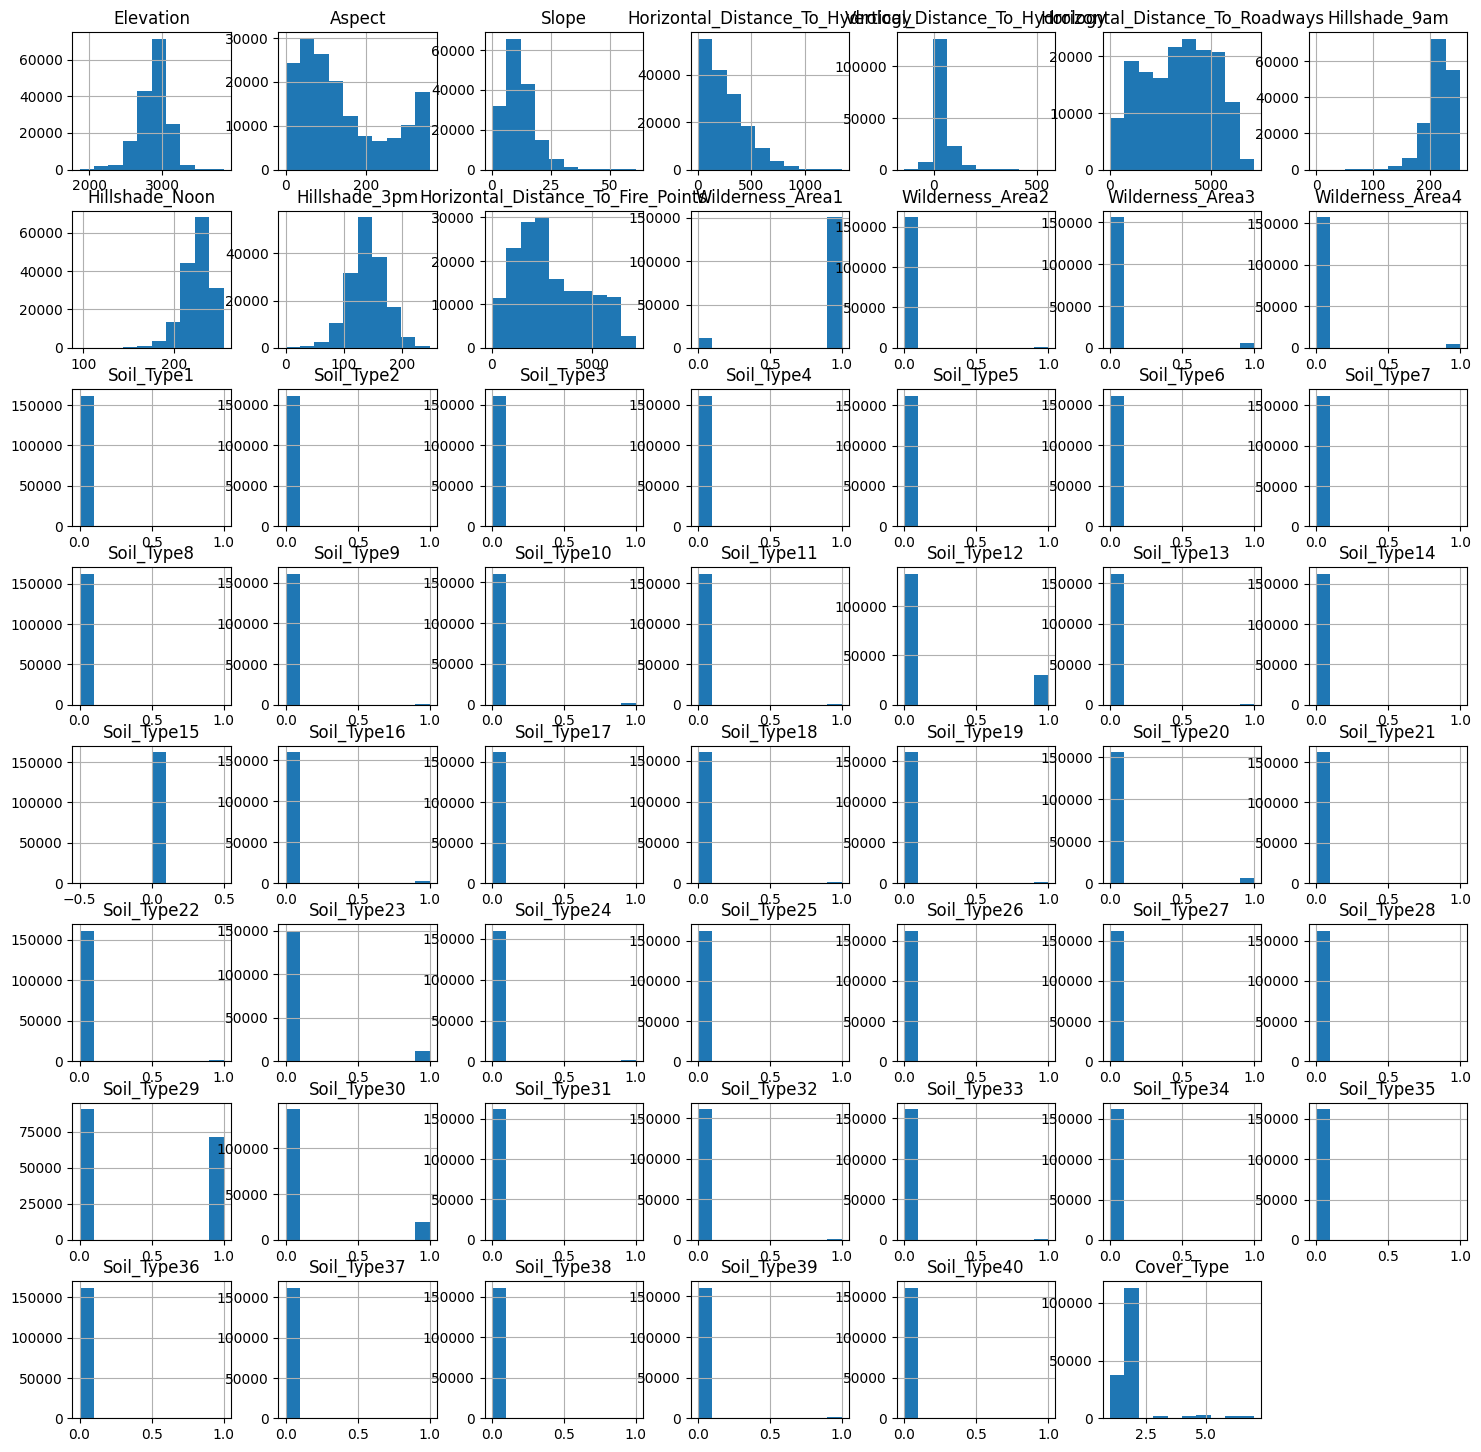

                                    Elevation    Aspect     Slope  \
Elevation                            1.000000  0.030272 -0.151397   
Aspect                               0.030272  1.000000  0.070229   
Slope                               -0.151397  0.070229  1.000000   
Horizontal_Distance_To_Hydrology     0.354249  0.014319 -0.098910   
Vertical_Distance_To_Hydrology       0.163890  0.097056  0.222760   
Horizontal_Distance_To_Roadways      0.691795  0.130890 -0.068992   
Hillshade_9am                        0.000761 -0.561704 -0.211745   
Hillshade_Noon                       0.154914  0.333022 -0.569144   
Hillshade_3pm                        0.109724  0.621017 -0.272872   
Horizontal_Distance_To_Fire_Points   0.152370 -0.052138 -0.173711   
Wilderness_Area1                     0.283873 -0.059209 -0.238418   
Wilderness_Area2                     0.122672  0.016394  0.014664   
Wilderness_Area3                     0.037738  0.036007  0.114430   
Wilderness_Area4                  

In [14]:
print(df["Cover_Type"].value_counts())

print("Missing values in Cover_Type:")
print(df["Cover_Type"].isnull().sum())
print(df.isnull().sum())

print("Total Missing Values:")
print(df.isnull().sum().sum())
df.hist(figsize=(18,18))
plt.show()
print(df.corr())


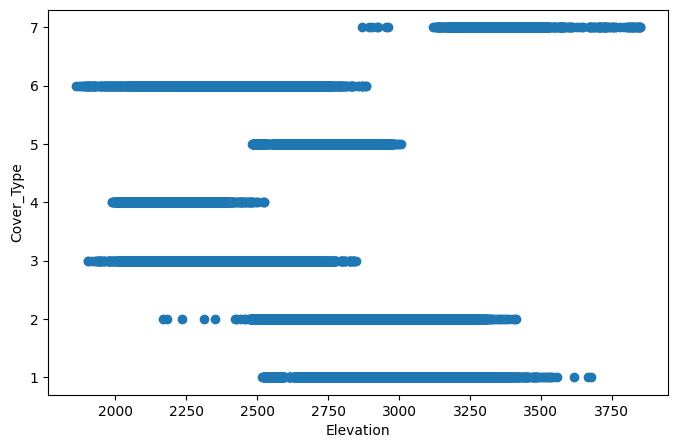

In [15]:
plt.figure(figsize=(8,5))
plt.scatter(df["Elevation"], df["Cover_Type"])
plt.xlabel("Elevation")
plt.ylabel("Cover_Type")
plt.show()

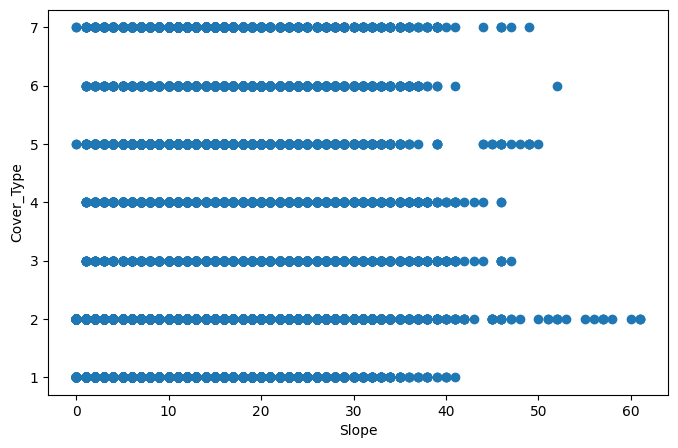

In [16]:
plt.figure(figsize=(8,5))
plt.scatter(df["Slope"], df["Cover_Type"])
plt.xlabel("Slope")
plt.ylabel("Cover_Type")
plt.show()

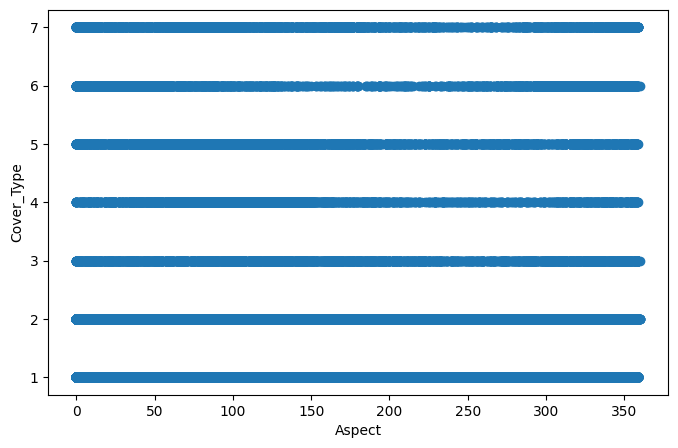

In [17]:
plt.figure(figsize=(8,5))
plt.scatter(df["Aspect"], df["Cover_Type"])
plt.xlabel("Aspect")
plt.ylabel("Cover_Type")
plt.show()

In [18]:
X = df.drop("Cover_Type", axis=1)

y = df["Cover_Type"]

print(X.shape)
print(y.shape)

(162097, 54)
(162097,)


In [19]:
print("NaN values in y:", y.isna().sum())

print("Total NaN values in X:", X.isna().sum().sum())

print(y.head())

print(y.tail())

print(y.dtype)
df = df.dropna(subset=["Cover_Type"])

X = df.drop("Cover_Type", axis=1)
y = df["Cover_Type"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

NaN values in y: 1
Total NaN values in X: 50
0    5.0
1    5.0
2    2.0
3    2.0
4    5.0
Name: Cover_Type, dtype: float64
162092    2.0
162093    2.0
162094    2.0
162095    1.0
162096    NaN
Name: Cover_Type, dtype: float64
float64
(129676, 54)
(32420, 54)
(129676,)
(32420,)


In [20]:
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.9450


In [21]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

         1.0       0.95      0.85      0.90      7455
         2.0       0.95      0.98      0.97     22623
         3.0       0.84      0.79      0.81       432
         4.0       0.93      0.98      0.95       432
         5.0       0.89      0.77      0.83       614
         6.0       0.83      0.87      0.85       432
         7.0       0.94      0.96      0.95       432

    accuracy                           0.95     32420
   macro avg       0.90      0.89      0.89     32420
weighted avg       0.94      0.95      0.94     32420


Confusion Matrix:

[[ 6373  1049     0     0    11     0    22]
 [  327 22236    11     0    33    13     3]
 [    0     3   341    19    11    58     0]
 [    0     0     7   422     0     3     0]
 [   12   116     9     0   474     3     0]
 [    0     3    40    11     2   376     0]
 [   16     0     0     0     0     0   416]]


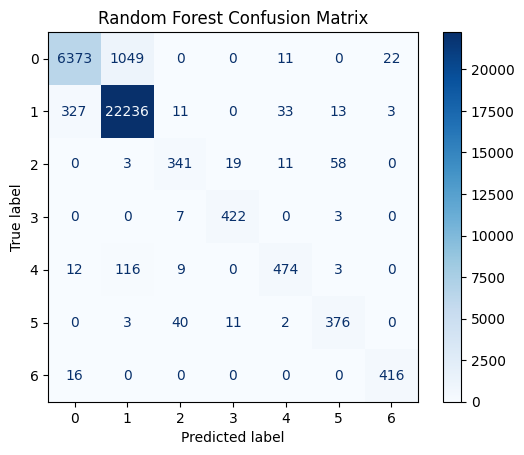

In [22]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [23]:
rf_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=25,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_tuned.fit(X_train, y_train)

y_pred_tuned = rf_tuned.predict(X_test)

In [24]:
print("Tuned Model Accuracy:", accuracy_score(y_test, y_pred_tuned))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_tuned))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_tuned))

Tuned Model Accuracy: 0.9308143121529919

Classification Report:

              precision    recall  f1-score   support

         1.0       0.95      0.80      0.86      7455
         2.0       0.93      0.98      0.96     22623
         3.0       0.83      0.78      0.80       432
         4.0       0.93      0.98      0.95       432
         5.0       0.88      0.71      0.78       614
         6.0       0.82      0.85      0.83       432
         7.0       0.94      0.96      0.95       432

    accuracy                           0.93     32420
   macro avg       0.90      0.86      0.88     32420
weighted avg       0.93      0.93      0.93     32420


Confusion Matrix:

[[ 5927  1488     0     0    15     0    25]
 [  293 22278     8     0    27    14     3]
 [    0     3   336    20    13    60     0]
 [    0     0     7   422     0     3     0]
 [   12   154    10     0   433     5     0]
 [    0     4    46    12     2   368     0]
 [   19     0     0     0     0     0   413]]


In [25]:
baseline_accuracy = accuracy_score(y_test, y_pred)
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

print("Baseline Accuracy :", baseline_accuracy)
print("Tuned Accuracy    :", tuned_accuracy)

if tuned_accuracy > baseline_accuracy:
    print("\nThe tuned Random Forest model performed better.")
elif tuned_accuracy == baseline_accuracy:
    print("\nBoth models achieved the same accuracy.")
else:
    print("\nThe baseline Random Forest model performed better.")

Baseline Accuracy : 0.9450339296730413
Tuned Accuracy    : 0.9308143121529919

The baseline Random Forest model performed better.


In [26]:
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

In [27]:
print("Gradient Boosting Accuracy:")
print(accuracy_score(y_test, gb_pred))

print("\nClassification Report:")
print(classification_report(y_test, gb_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, gb_pred))

Gradient Boosting Accuracy:
0.8610117211597779

Classification Report:
              precision    recall  f1-score   support

         1.0       0.83      0.60      0.70      7455
         2.0       0.87      0.96      0.91     22623
         3.0       0.69      0.68      0.69       432
         4.0       0.92      0.96      0.94       432
         5.0       0.71      0.56      0.63       614
         6.0       0.74      0.71      0.72       432
         7.0       0.90      0.91      0.90       432

    accuracy                           0.86     32420
   macro avg       0.81      0.77      0.78     32420
weighted avg       0.86      0.86      0.85     32420


Confusion Matrix:
[[ 4448  2939     0     0    24     2    42]
 [  811 21717     6     0    70    16     3]
 [    0     1   294    29    28    80     0]
 [    0     0    13   413     0     6     0]
 [   33   214    16     0   345     6     0]
 [    0     3    95     9    19   306     0]
 [   41     0     0     0     0     0   391

In [28]:
rf_accuracy = accuracy_score(y_test, y_pred)
gb_accuracy = accuracy_score(y_test, gb_pred)

print("Random Forest Accuracy :", rf_accuracy)
print("Gradient Boosting Accuracy :", gb_accuracy)

if rf_accuracy > gb_accuracy:
    print("Random Forest performed better.")
else:
    print("Gradient Boosting performed better.")
best_model = rf_model if rf_accuracy >= gb_accuracy else gb_model

Random Forest Accuracy : 0.9450339296730413
Gradient Boosting Accuracy : 0.8610117211597779
Random Forest performed better.


In [29]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
0,Elevation,0.240961
5,Horizontal_Distance_To_Roadways,0.142271
9,Horizontal_Distance_To_Fire_Points,0.114811
3,Horizontal_Distance_To_Hydrology,0.063163
4,Vertical_Distance_To_Hydrology,0.060321
1,Aspect,0.048147
8,Hillshade_3pm,0.044683
10,Wilderness_Area1,0.043472
7,Hillshade_Noon,0.042022
6,Hillshade_9am,0.041090


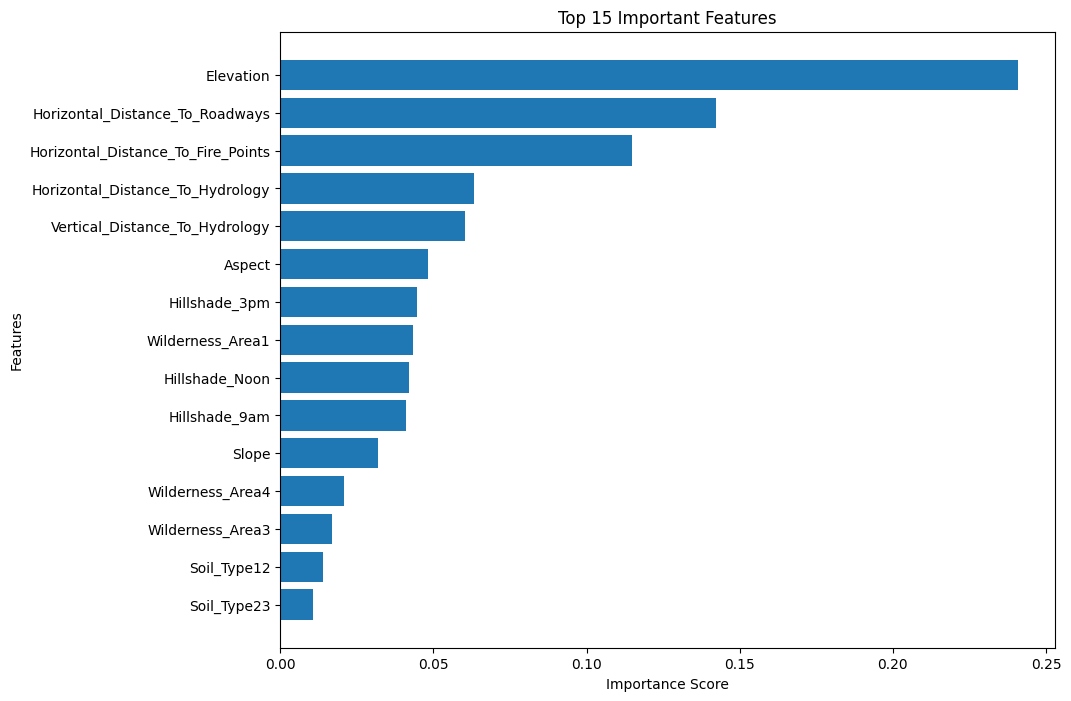

In [30]:
plt.figure(figsize=(10,8))

plt.barh(
    feature_importance["Feature"][:15],
    feature_importance["Importance"][:15]
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 15 Important Features")

plt.gca().invert_yaxis()

plt.show()

In [31]:
joblib.dump(best_model, "forest_cover_classifier.pkl")

print("Model saved successfully.")
loaded_model = joblib.load("forest_cover_classifier.pkl")

print("Model loaded successfully.")

Model saved successfully.
Model loaded successfully.


In [32]:
sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)

print("Actual Class :", y_test.iloc[0])
print("Predicted Class :", prediction[0])

Actual Class : 2.0
Predicted Class : 2.0


In [33]:
sample_data = X_test.iloc[:5]

predictions = loaded_model.predict(sample_data)

results = pd.DataFrame({
    "Actual": y_test.iloc[:5].values,
    "Predicted": predictions
})

results

,Actual,Predicted
0,2.0,2.0
1,2.0,2.0
2,2.0,2.0
3,2.0,2.0
4,2.0,2.0


In [34]:
cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

In [35]:
print("Cross Validation Scores")

print(cv_scores)

print("\nAverage Accuracy:")

print(cv_scores.mean())

print("\nStandard Deviation:")

print(cv_scores.std())

Cross Validation Scores
[0.67751388 0.85406706 0.80863074 0.83386286 0.80085752]

Average Accuracy:
0.7949864122034589

Standard Deviation:
0.061680360441608385


In [ ]:
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=1
)

grid_search.fit(X_train, y_train)

In [ ]:
print("Best Parameters")

print(grid_search.best_params_)

print("\nBest Accuracy")

print(grid_search.best_score_)

In [ ]:
best_rf = grid_search.best_estimator_
best_prediction = best_rf.predict(X_test)
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test,best_prediction))

In [ ]:
print(classification_report(
    y_test,
    best_prediction
))
cm = confusion_matrix(
    y_test,
    best_prediction
)

print(cm)

In [ ]:
ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot(cmap="Blues")

In [ ]:
joblib.dump(best_rf, "forest_cover_classifier.pkl")
print("Model saved successfully.")
loaded_model = joblib.load("forest_cover_classifier.pkl")
print("Model loaded successfully.")
sample = X_test.iloc[[0]]
prediction = loaded_model.predict(sample)
print("Predicted Forest Cover Type:", prediction[0])

In [ ]:
print("Actual Class:", y_test.iloc[0])
print("Predicted Class:", prediction[0])
predictions = loaded_model.predict(X_test.iloc[:10])
comparison = X_test.iloc[:10].copy()
comparison["Actual"] = y_test.iloc[:10].values
comparison["Predicted"] = predictions
comparison[["Actual", "Predicted"]]

In [ ]:
st.set_page_config(
    page_title="Forest Cover Type Classifier",
    page_icon="🌲"
)

st.title("🌲 Forest Cover Type Classifier")
st.write("Predict the forest cover type using cartographic features.")

In [ ]:
elevation = st.number_input("Elevation", value=2500)

aspect = st.number_input("Aspect", value=100)

slope = st.number_input("Slope", value=10)

horizontal_distance_to_hydrology = st.number_input(
    "Horizontal Distance To Hydrology",
    value=150
)

vertical_distance_to_hydrology = st.number_input(
    "Vertical Distance To Hydrology",
    value=20
)

horizontal_distance_to_roadways = st.number_input(
    "Horizontal Distance To Roadways",
    value=1000
)

hillshade_9am = st.number_input("Hillshade 9am", value=220)

hillshade_noon = st.number_input("Hillshade Noon", value=230)

hillshade_3pm = st.number_input("Hillshade 3pm", value=140)

horizontal_distance_to_fire_points = st.number_input(
    "Horizontal Distance To Fire Points",
    value=1200
)
st.button("Predict")